In [1]:
from faker import Faker
import pandas as pd
import numpy as np
import random

fake = Faker()

num_patients = 400

diagnoses = ["Flu", "Diabetes", "Hypertension", "Covid-19", "Heart Disease"]

data = []


In [2]:
for i in range(num_patients):
    age = random.randint(1, 90)
    
    # hospital days depend on disease
    hospital_days = random.randint(1, 15)
    
    # cost depends on days + disease severity
    base_cost = hospital_days * random.randint(2000, 10000)
    
    data.append({
        "patient_id": i + 1,
        "age": age,
        "gender": random.choice(["Male", "Female"]),
        "diagnosis": random.choice(diagnoses),
        "hospital_days": hospital_days,
        "treatment_cost": base_cost + random.randint(-5000, 5000)
    })

In [3]:
df = pd.DataFrame(data)
df.head()

,patient_id,age,gender,diagnosis,hospital_days,treatment_cost
0,1,84,Female,Flu,9,51302
1,2,69,Female,Diabetes,11,63427
2,3,85,Female,Hypertension,10,86424
3,4,45,Female,Hypertension,15,65700
4,5,37,Female,Covid-19,6,52942


In [4]:
avg_stay = df.groupby("diagnosis")["hospital_days"].mean()

print(avg_stay)

diagnosis
Covid-19         7.831461
Diabetes         7.720588
Flu              6.853333
Heart Disease    8.132530
Hypertension     8.364706
Name: hospital_days, dtype: float64


In [5]:
def age_group(age):
    if age <= 18:
        return "Child"
    elif age <= 40:
        return "Young Adult"
    elif age <= 60:
        return "Middle Age"
    else:
        return "Senior"

df["age_group"] = df["age"].apply(age_group)

print(df[["age", "age_group"]].head())

   age    age_group
0   84       Senior
1   69       Senior
2   85       Senior
3   45   Middle Age
4   37  Young Adult


In [ ]:
mean_cost = np.mean(df["treatment_cost"])
std_cost = np.std(df["treatment_cost"])

df["z_score"] = (df["treatment_cost"] - mean_cost) / std_cost

threshold = 3
df["is_anomaly"] = np.abs(df["z_score"]) > threshold

print(df[df["is_anomaly"]])

     patient_id  age  gender diagnosis  hospital_days  treatment_cost  \
272         273   69  Female  Covid-19             15          150871   

    age_group  z_score  is_anomaly  
272    Senior  3.20617        True  


In [7]:
df["log_cost"] = np.log1p(df["treatment_cost"])

e:\Bl_Python_Training\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
df["cost_norm"] = (df["treatment_cost"] - df["treatment_cost"].min()) / (
    df["treatment_cost"].max() - df["treatment_cost"].min()
)

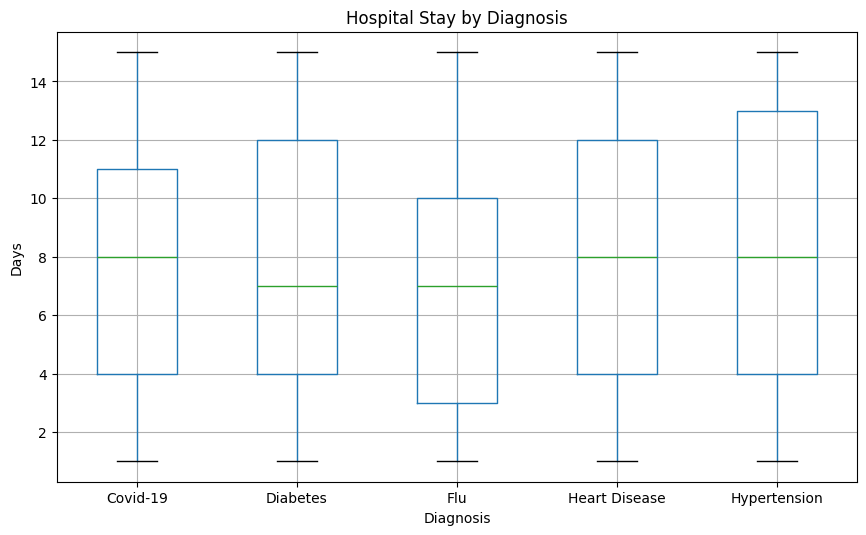

In [9]:
import matplotlib.pyplot as plt

df.boxplot(column="hospital_days", by="diagnosis", figsize=(10, 6))

plt.title("Hospital Stay by Diagnosis")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("Days")

plt.show()

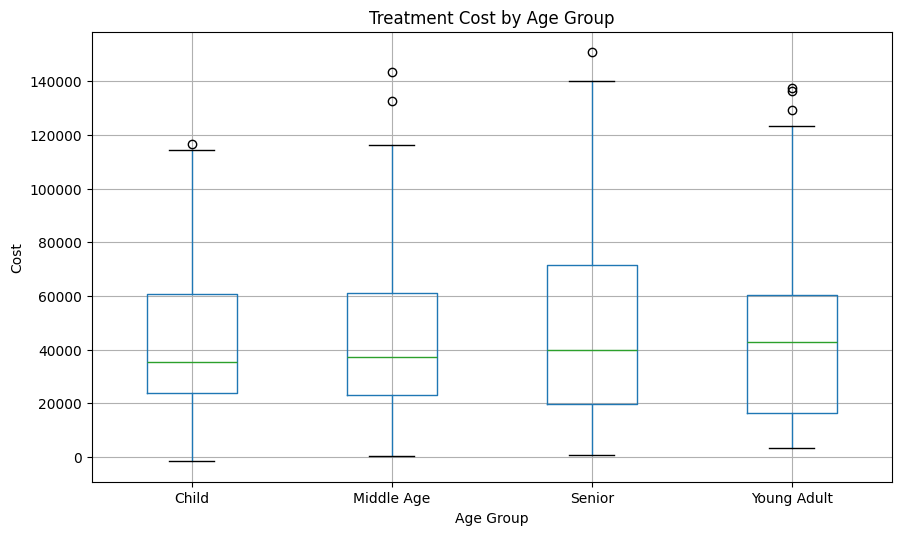

In [10]:
df.boxplot(column="treatment_cost", by="age_group", figsize=(10, 6))

plt.title("Treatment Cost by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("Cost")

plt.show()